<a href="https://colab.research.google.com/github/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/blob/main/aprendizado_profundo/projeto_transformers/Desafio_Deep_Learning_para_Transformadores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Preparação do ambiente e dos dados**

### **1. Instalação e importação das bibliotecas**

In [100]:
import importlib.util
import os

def verificar_e_instalar(bibliotecas):
    faltantes = []
    for lib in bibliotecas:
        spec = importlib.util.find_spec(lib)
        if spec is None:
            faltantes.append(lib)

    if faltantes:
        print(f"Instalando bibliotecas faltantes: {', '.join(faltantes)}")
        # Usando -q para uma saída mais limpa no Colab
        libs_str = " ".join(faltantes)
        os.system(f"pip install -q {libs_str}")
        print("Instalação concluída.")
    else:
        print("Todas as bibliotecas necessárias já estão instaladas.")

# Lista de bibliotecas necessárias para o projeto
libs_projeto = ["tensorflow", "scikit-learn", "pandas", "matplotlib", "tabulate"]

verificar_e_instalar(libs_projeto)

Instalando bibliotecas faltantes: scikit-learn
Instalação concluída.


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tabulate
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

### **2. Carregamento e análise inicial dos dados**

╔═══════════════════════════════════════════════════════════════════════════╗
║                       Relatório de Saúde do Dataset                       ║
╠═══════════════════════════════════════════════════════════════════════════╣
║ =>> Origem: https://raw.githubusercontent.com/marantmir/pos_graduacao_ia_ ║
║ =>> Dimensões: 17348 linhas x 9 colunas                                   ║
║ =>> Período: 2016-07-03 até 2018-06-25                                    ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                    Distribuição da Variável Alvo class                    ║
╠═══════════════════════════════════════════════════════════════════════════╣
║ Classe          | Contagem             | Porcentagem (%)                  ║
║ --------------- | -------------------- | -------------------------------- ║
║ 0.0             | 17175.0              | 99.0                             ║
║ 1.0             | 173.0                | 1.0                  

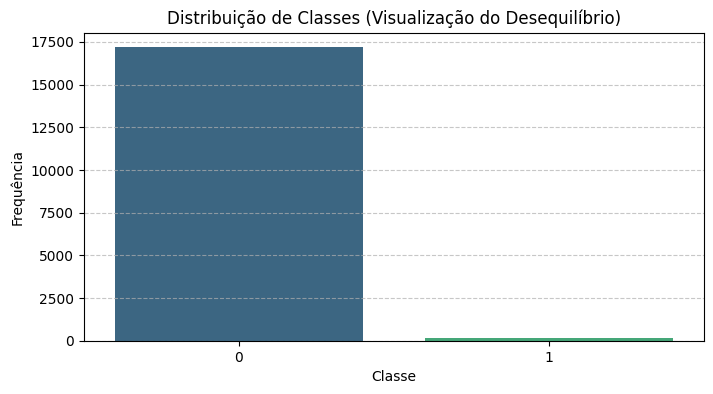


╔══════════════════════════════════════════════════════════════════════════════════════════════╗
║                                Amostra cronológica dos dados                                 ║
╚══════════════════════════════════════════════════════════════════════════════════════════════╝
| date                |   HUFL |   HULL |   MUFL |   MULL |   LUFL |   LULL |     OT |   class |
|:--------------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|--------:|
| 2016-07-03 00:00:00 | 10.382 |  5.425 |  7.604 |  2.31  |  2.955 |  1.675 | 29.335 |       0 |
| 2016-07-03 01:00:00 |  9.779 |  5.224 |  6.716 |  2.843 |  2.65  |  1.675 | 26.028 |       0 |
| 2016-07-03 02:00:00 | 10.382 |  4.689 |  7.32  |  2.203 |  2.985 |  1.858 | 24.34  |       0 |
| 2016-07-03 03:00:00 |  9.779 |  4.153 |  6.823 |  1.99  |  2.528 |  1.675 | 26.45  |       0 |
| 2016-07-03 04:00:00 | 10.717 |  4.756 |  7.356 |  2.807 |  2.65  |  1.797 | 25.958 |       0 |

░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [105]:
# URL e Carregamento
url = "https://raw.githubusercontent.com/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/refs/heads/main/aprendizado_profundo/projeto_transformers/transformers.csv"
dados = pd.read_csv(url)

# --- Processamento ---
# Conversão com tratamento de erros conforme boas práticas
dados['date'] = pd.to_datetime(dados['date'], errors='coerce')
dados = dados.sort_values("date").reset_index(drop=True)

# --- Relatório Unificado com Bordas ---
largura = 75
print("╔" + "═"*largura + "╗")
print(f"║ {'Relatório de Saúde do Dataset'.center(largura-2)} ║")
print("╠" + "═"*largura + "╣")
print(f"║ =>> Origem: {url[:61]:<57} ║")
print(f"║ =>> Dimensões: {str(dados.shape[0]) + ' linhas x ' + str(dados.shape[1]) + ' colunas':<58} ║")

# Verificação de datas para evitar erro no strftime se houver NaT
data_min = dados['date'].min().strftime('%Y-%m-%d') if pd.notnull(dados['date'].min()) else "N/A"
data_max = dados['date'].max().strftime('%Y-%m-%d') if pd.notnull(dados['date'].max()) else "N/A"
print(f"║ =>> Período: {data_min} até {data_max:<45} ║")

print("╠" + "═"*largura + "╣")
print(f"║ {'Distribuição da Variável Alvo ''class'''.center(largura-2)} ║")
print("╠" + "═"*largura + "╣")

# Cálculo de Estatísticas
stats = pd.DataFrame({
    'Contagem': dados['class'].value_counts(),
    'Porcentagem (%)': (dados['class'].value_counts(normalize=True) * 100).round(2)
}).reset_index()

# Imprimindo a tabela dentro da borda
print(f"║ {'Classe':<15} | {'Contagem':<20} | {'Porcentagem (%)':<32} ║")
print(f"║ {'-'*15:<15} | {'-'*20:<20} | {'-'*32:<32} ║")

for _, row in stats.iterrows():
    linha = f"║ {str(row['class']):<15} | {str(row['Contagem']):<20} | {str(row['Porcentagem (%)']):<32} ║"
    print(linha)

print("╚" + "═"*largura + "╝")

# --- Visualização Gráfica ---
plt.figure(figsize=(8, 4))
sns.countplot(x='class', data=dados, palette='viridis', hue='class', legend=False)
plt.title('Distribuição de Classes (Visualização do Desequilíbrio)')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Amostra Final Estilizada ---
print("\n" + "╔" + "═" * (largura+19) + "╗")
print(f"║ {'Amostra cronológica dos dados'.center(largura+17)} ║")
print("╚" + "═" * (largura+19) + "╝")

# Usando o to_markdown para a tabela, centralizando-a visualmente
print(dados.head().to_markdown(index=False))

print("\n" + "░" * (largura + 21))
print(" Fim do Relatório Inicial ".center(largura + 21, '░'))
print("░" * (largura + 21))

**Explicação**

- A coluna `date` representa a data e hora da medição. Como o problema envolve série temporal, é fundamental ordenar os dados cronologicamente.

- A coluna `class` indica a condição operacional:
  - 0 = normal
  - 1 = falha ou potencial risco

Como há poucos registros com `class = 1`, o problema de classificação é desbalanceado.

Por isso, no modelo **MLP**, vamos usar `class_weight`.

## **Detecção de Anomalias com Autoencoder**
**Ideia do Autoencoder**

- Um Autoencoder aprende a copiar a entrada para a saída. Parece simples, mas existe uma compressão no meio da rede.

- Ele aprende o padrão dos dados normais. Quando aparece algo muito diferente, ele não consegue reconstruir bem. Esse erro de reconstrução indica possível anomalia.

- No contexto dos transformadores:
  - **Entrada:** cargas elétricas + temperatura do óleo
  - **Saída esperada:** reconstrução dessas mesmas variáveis
  - **Erro alto:** comportamento estranho
  - **Erro baixo:** comportamento normal

### **3. Preparação dos dados para o Autoencoder**

In [112]:
# Definindo as features (Sensores)
features_ae = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

# Usando o StandardScaler para escalonar os dados pois Autoencoders convergem melhor com dados centralizados
scaler_ae = StandardScaler()
X_ae_scaled = scaler_ae.fit_transform(dados[features_ae])

# Filtrando de Dados Normais
# Para detecção de anomalias, o Autoencoder deve aprender apenas o padrão 'Normal'
mask_normal = (dados["class"] == 0)
X_normal = X_ae_scaled[mask_normal]

# Dividindo os dados para Treino e Validação
X_train_ae, X_val_ae = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Relatório de Preparação
print("╔" + "═"*48 + "╗")
print(f"║ {'Preparação para Autoecnoder Concluída'.center(46)} ║")
print("╠" + "═"*48 + "╣")
print(f"║ -> Features selecionadas: {len(features_ae):<20} ║")
print(f"║ -> Amostras de Treino:    {X_train_ae.shape[0]:<20} ║")
print(f"║ -> Amostras de Validação: {X_val_ae.shape[0]:<20} ║")
print(f"║ -> Média Global (Scaled): {X_train_ae.mean():.4f} (Ideal: ~0)  ║")
print("╚" + "═"*48 + "╝")

╔════════════════════════════════════════════════╗
║     Preparação para Autoecnoder Concluída      ║
╠════════════════════════════════════════════════╣
║ -> Features selecionadas: 7                    ║
║ -> Amostras de Treino:    13740                ║
║ -> Amostras de Validação: 3435                 ║
║ -> Média Global (Scaled): -0.0034 (Ideal: ~0)  ║
╚════════════════════════════════════════════════╝
